# MODUL PRAKTIKUM DAN PENUGASAN


### Penjelasan Tahap 1 : 

=== Distance Matrix (Euclidean) ===
          a         b         c         d         e         f
a  0.000000  0.707107  5.656854  3.605551  4.242641  3.201562
b  0.707107  0.000000  4.949747  2.915476  3.535534  2.500000
c  5.656854  4.949747  0.000000  2.236068  1.414214  2.500000
d  3.605551  2.915476  2.236068  0.000000  1.000000  0.500000
e  4.242641  3.535534  1.414214  1.000000  0.000000  1.118034
f  3.201562  2.500000  2.500000  0.500000  1.118034  0.000000


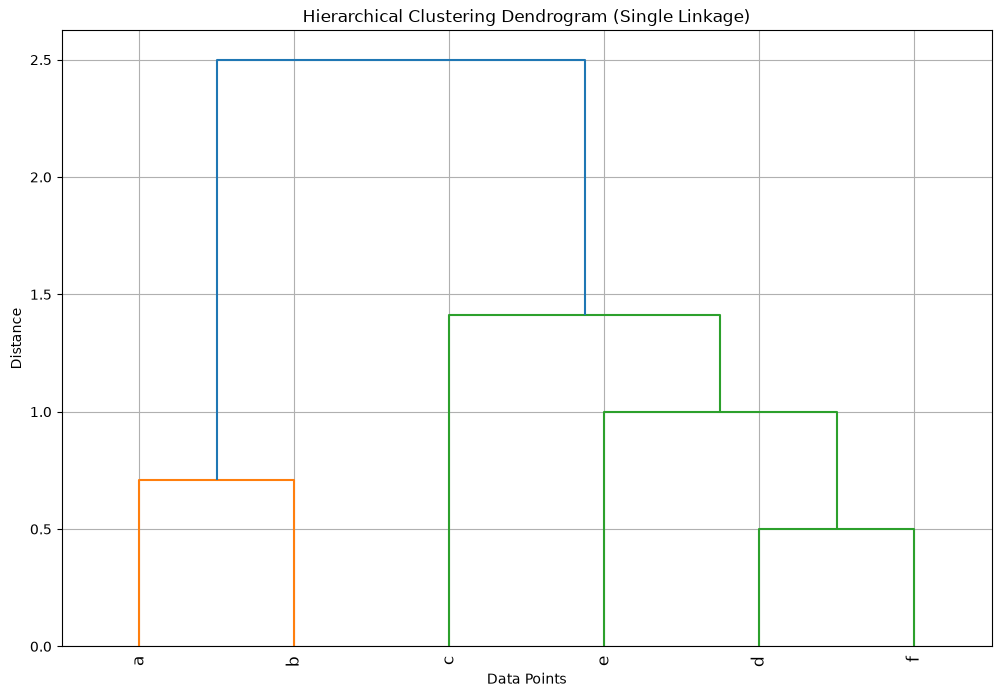

In [1]:
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
# 1. Dataset sederhana
data = np.array([
 [1.0, 1.0], # a
 [1.5, 1.5], # b
 [5.0, 5.0], # c
 [3.0, 4.0], # d
 [4.0, 4.0], # e
 [3.0, 3.5] # f
])
# 2. Hitung Distance Matrix (Euclidean Distance)
distance_matrix = pdist(data, metric='euclidean')
distance_df = pd.DataFrame(squareform(distance_matrix),
 columns=['a', 'b', 'c', 'd', 'e', 'f'],
 index=['a', 'b', 'c', 'd', 'e', 'f'])
# 3. Tampilkan Distance Matrix
print("=== Distance Matrix (Euclidean) ===")
print(distance_df)
# 4. Hierarchical Clustering (Single Linkage)
linked = linkage(data, method='single')
# 5. Plot Dendrogram
plt.figure(figsize=(12, 8))
plt.title("Hierarchical Clustering Dendrogram (Single Linkage)")
dendrogram(linked, labels=['a', 'b', 'c', 'd', 'e', 'f'], leaf_rotation=90)
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

Kode ini membaca file Mall_Customers.csv dan menyimpannya dalam variabel df. Perintah df.head() menampilkan lima baris pertama agar kita dapat melihat isi serta nama kolom dataset.

In [2]:
import pandas as pd
df = pd.read_csv("Mall_Customers.csv")
df.head()


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Kode ini membaca file Mall_Customers.csv dan menyimpannya dalam variabel df. Perintah df.head() menampilkan lima baris pertama agar kita dapat melihat isi serta nama kolom dataset.

In [3]:
x = df.iloc[:, [3, 4]].values


Kode ini mengambil seluruh baris pada kolom indeks 3 dan 4, yaitu Annual Income dan Spending Score. Kedua kolom tersebut diubah menjadi array melalui .values dan disimpan dalam variabel x. Data ini digunakan untuk mengelompokkan pelanggan berdasarkan pendapatan dan skor belanjanya.

In [4]:
from sklearn.preprocessing import StandardScaler
data_scaler = StandardScaler()
scaled_data = data_scaler.fit_transform(x)
scaled_data.shape


(200, 2)

Kode ini menggunakan StandardScaler untuk menyesuaikan skala pendapatan dan skor belanja agar keduanya memiliki pengaruh yang lebih sebanding dalam perhitungan jarak. Hasilnya disimpan dalam scaled_data. Perintah scaled_data.shape menampilkan ukuran data, yaitu 200 baris dan 2 kolom pada dataset dalam modul.

In [5]:

from scipy.cluster.hierarchy import linkage, dendrogram
clustering = linkage(scaled_data, method="complete", metric="euclidean")

Kode ini menjalankan Hierarchical Clustering pada data yang sudah distandardisasi. Metode complete linkage menentukan jarak antarkelompok berdasarkan pasangan titik yang paling jauh dari kedua kelompok, dengan jarak Euclidean sebagai ukuran jaraknya. Urutan penggabungan kelompok disimpan dalam variabel clustering.

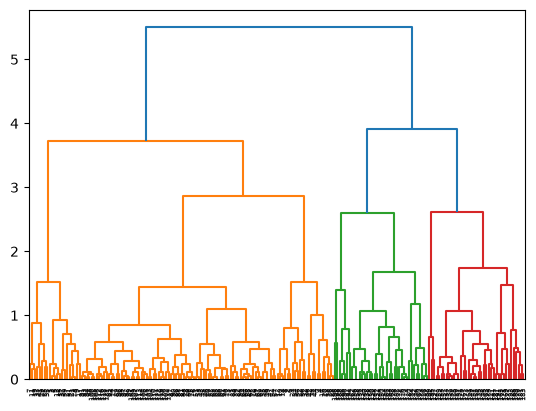

In [6]:
import matplotlib.pyplot as plt
dendrogram(clustering)
plt.show()


Kode ini menampilkan dendrogram berdasarkan hasil clustering. Grafik menunjukkan bagaimana pelanggan atau kelompok pelanggan digabungkan secara bertahap. Semakin rendah posisi penggabungan, semakin mirip kelompok tersebut menurut metode yang digunakan. Dendrogram dapat membantu menentukan jumlah kelompok dengan memilih ketinggian pemotongan.
Warna cabang saja belum menunjukkan kategori pelanggan dengan pengeluaran rendah, sedang, atau tinggi. Untuk memberikan kategori tersebut, isi setiap kelompok perlu diperiksa terlebih dahulu.

# TUGAS
##### Pada percobaan pertama dengan dataset sederhana, bandingkan hasil plot dendrogram single linkage dengan complete linkage dan average linkage



In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

# Dataset sederhana sesuai modul
data = np.array([
    [1.0, 1.0],  # a
    [1.5, 1.5],  # b
    [5.0, 5.0],  # c
    [3.0, 4.0],  # d
    [4.0, 4.0],  # e
    [3.0, 3.5]   # f
])

labels = ["a", "b", "c", "d", "e", "f"]

Kode ini mengimpor pustaka untuk mengolah data dan membuat grafik, lalu menyiapkan enam titik sesuai modul. Label a sampai f digunakan untuk mengenali setiap titik pada dendrogram.

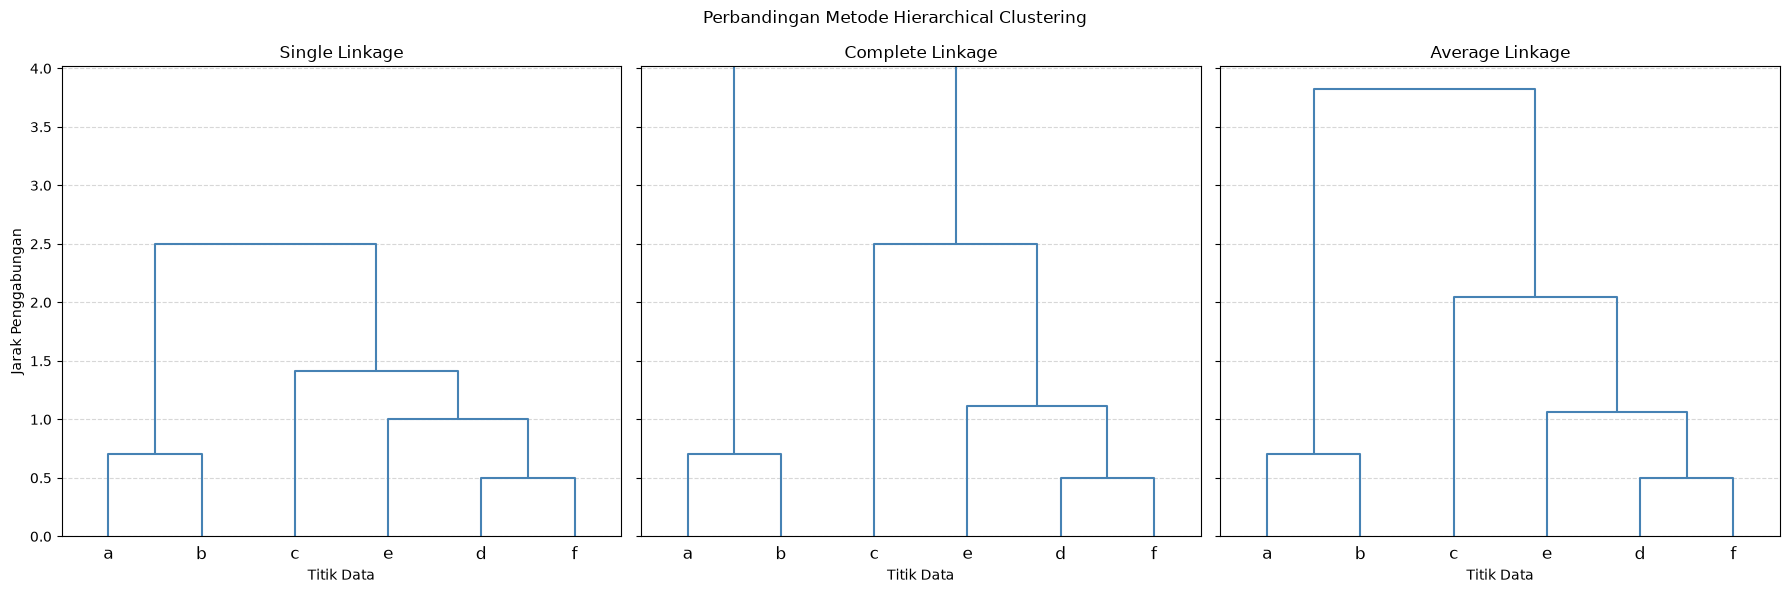

In [9]:
# Metode yang akan dibandingkan
methods = ["single", "complete", "average"]

# Menyimpan hasil pengelompokan setiap metode
hasil_linkage = {}

# Membuat tiga grafik dengan skala sumbu Y yang sama
fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6),
    sharey=True
)

for ax, method in zip(axes, methods):
    # Melakukan hierarchical clustering
    linked = linkage(
        data,
        method=method,
        metric="euclidean"
    )

    hasil_linkage[method] = linked

    # Menampilkan dendrogram
    dendrogram(
        linked,
        labels=labels,
        ax=ax,
        color_threshold=0,
        above_threshold_color="steelblue"
    )

    ax.set_title(f"{method.capitalize()} Linkage")
    ax.set_xlabel("Titik Data")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

axes[0].set_ylabel("Jarak Penggabungan")

plt.suptitle("Perbandingan Metode Hierarchical Clustering")
plt.tight_layout()
plt.show()

Kode ini menjalankan pengelompokan menggunakan single, complete, dan average linkage, lalu menampilkan ketiga dendrogram secara berdampingan. Skala sumbu vertikal dibuat sama agar perbedaan tinggi penggabungan dapat dibandingkan dengan jelas.

In [10]:
# Kolom indeks 2 pada hasil linkage berisi jarak penggabungan
tabel_jarak = pd.DataFrame({
    "Tahap": range(1, len(data)),
    "Single": hasil_linkage["single"][:, 2],
    "Complete": hasil_linkage["complete"][:, 2],
    "Average": hasil_linkage["average"][:, 2]
})

print(tabel_jarak.round(3).to_string(index=False))

 Tahap  Single  Complete  Average
     1   0.500     0.500    0.500
     2   0.707     0.707    0.707
     3   1.000     1.118    1.059
     4   1.414     2.500    2.050
     5   2.500     5.657    3.826


Kode ini mengambil jarak penggabungan dari setiap metode dan menyusunnya dalam tabel. Nilainya dibulatkan menjadi tiga angka desimal agar perbedaan antarmetode lebih mudah dibaca.

### Analisis perbandingan untuk jawaban tugas
Pada dataset ini, ketiga metode menghasilkan urutan penggabungan yang sama, tetapi memiliki tinggi percabangan yang berbeda. Titik d dan f bergabung terlebih dahulu karena jaraknya paling dekat, kemudian titik a dan b. Setelah itu, e bergabung dengan kelompok d dan f, disusul c, hingga seluruh data menjadi satu kelompok.
Single linkage menggunakan jarak pasangan titik terdekat antarkelompok sehingga menghasilkan jarak penggabungan yang lebih rendah. Complete linkage menggunakan jarak pasangan titik terjauh sehingga jarak penggabungannya lebih tinggi. Average linkage menggunakan rata-rata jarak seluruh pasangan titik antarkelompok sehingga hasilnya berada di antara kedua metode tersebut pada data ini.
Jika dendrogram dipotong sehingga membentuk dua kelompok, ketiga metode menghasilkan kelompok yang sama, yaitu {a, b} dan {c, d, e, f}. Jadi, perbedaan utama pada contoh ini terletak pada jarak penggabungannya, bukan anggota dua kelompok akhirnya.